# Playground to manually test a few architectures/hyperparameters
## Train LSTM pipeline and plot rolling forecasts for test profiles

In [1]:
from pathlib import Path

from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
    save_forecast_profiles_pdf,
)

In [2]:
batch_size = 1024
epochs = 50
seed = 123
max_plots = 5

n_lstm = 1
lstm_hidden = 256              # shared across stacked layers
lstm_dropout = 0.3            # ignored if n_lstm == 1 in nn.LSTM

n_fc = 1
fc_hidden = (512,)

learning_rate = 3e-4
preload_training_data = True


h5_path = Path("../outputs/datasets/scaled_split/lstm_merged_batches_0003_k12_minmax_train0.70_val0.15_test0.15.h5")
out_dir = Path(f"../outputs/ml_results/training_playground/N501/Batch0003_k12_minmax/")
out_dir.mkdir(parents=True, exist_ok=True)

print("h5_path exists:", h5_path.exists())
print("out_dir:", out_dir)

h5_path exists: True
out_dir: ../outputs/ml_results/training_playground/N501/Batch0003_k12_minmax


In [3]:
config = LSTMPipelineConfig(
    h5_path=h5_path,
    batch_size=batch_size,
    seed=seed,
    n_lstm=n_lstm,
    lstm_hidden=lstm_hidden,
    lstm_dropout=lstm_dropout,
    n_fc=n_fc,
    fc_hidden=tuple(fc_hidden),
    learning_rate=learning_rate,
    use_tqdm=False,
)

pipeline = LSTMPipeline(config)

datasets = pipeline.build()
pipeline.inspect()

Dataset summary:
  H5 path:         ../outputs/datasets/scaled_split/lstm_merged_batches_0003_k12_minmax_train0.70_val0.15_test0.15.h5
  Batch size:      1024
  Seed:            123

  Train profiles:  700
  Val profiles:    150
  Test profiles:   150

  Sample X shape:  (501, 13, 14)   (per-sample)
  Sample Y shape:  (501, 13)   (per-sample)

  Train samples:   350,700  (~343 batches)
  Val samples:     75,150  (~74 batches)
  Test samples:    75,150  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          343
    val_samples:    74
    val_profile_ds: 150
    test_profile_ds:150

Train batch X shape: torch.Size([1024, 13, 14])
Train batch Y shape: torch.Size([1024, 13])

Val profile: results_drum_profile_02008
  X profile shape: torch.Size([501, 13, 14])
  Y profile shape: torch.Size([501, 13])

Test profile: results_drum_profile_02004
  X profile shape: torch.Size([501, 13, 14])
  Y profile shape: torch.Size([501, 13])



Using GPU: NVIDIA A100-SXM4-40GB

Deterministic seed set to: 123
LSTMRegressor architecture:
  Input features: 14
  LSTM layers (1): hidden_size=256, dropout=0.3
  FC layers (1): [512]
  Output targets: 13



/home/burnloga2/miniforge3/envs/rabl/lib/python3.11/site-packages/torch/nn/modules/rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Preloaded 343 training batches to cuda:0 in 5.77s.
Epoch 1/50 - loss: 1.19885e-02 - val_loss: 5.80219e-04 - lr: 3.000e-04 - data_wait: 0.00s - h2d: 0.00s - compute: 1.45s - val_time: 1.56s - epoch_total: 3.01s - preloaded: True - preload_time: 5.77s - max_cuda_mem: 546.63 MB - io_h5: 2.38s - io_cast: 0.02s - io_profiles: 703 - io_samples: 351724 - io_tput: 146088.46 samp/s - io_frac_of_data_wait: 1365637.26%
Epoch 1/50 total_time_s: 3.01
Epoch 2/50 - loss: 2.30140e-04 - val_loss: 1.28400e-04 - lr: 3.000e-04 - data_wait: 0.00s - h2d: 0.00s - compute: 0.96s - val_time: 1.32s - epoch_total: 2.28s - preloaded: True - preload_time: 5.77s - max_cuda_mem: 546.63 MB - io_h5: 0.00s - io_cast: 0.00s - io_profiles: 0 - io_samples: 0 - io_tput: 0.00 samp/s - io_frac_of_data_wait: 0.00%
Epoch 2/50 total_time_s: 2.28
Epoch 3/50 - loss: 8.78374e-05 - val_loss: 8.94488e-05 - lr: 3.000e-04 - data_wait: 0.00s - h2d: 0.00s - compute: 0.95s - val_time: 1.07s - epoch_total: 2.02s - preloaded: True - preloa

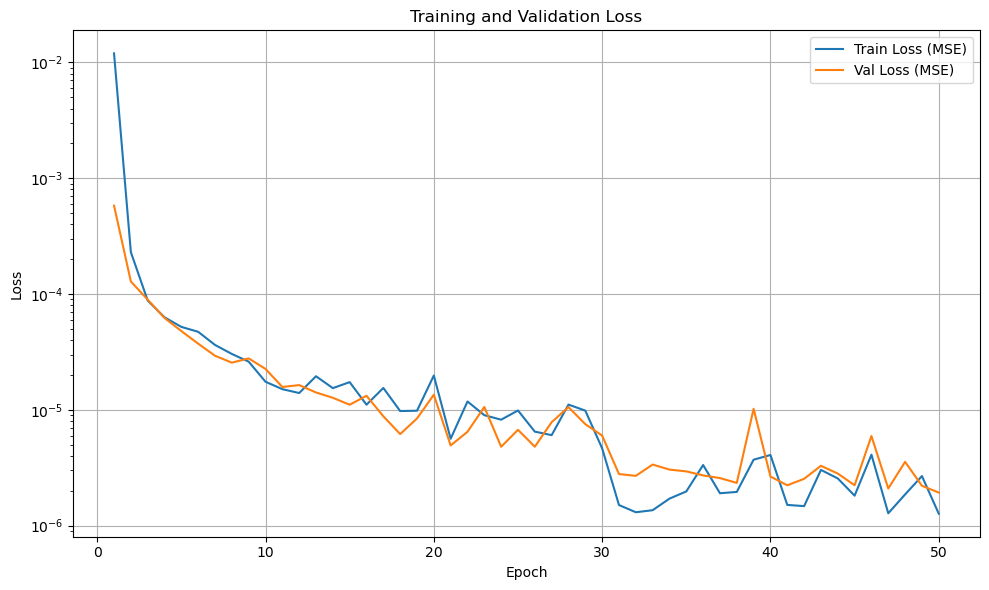

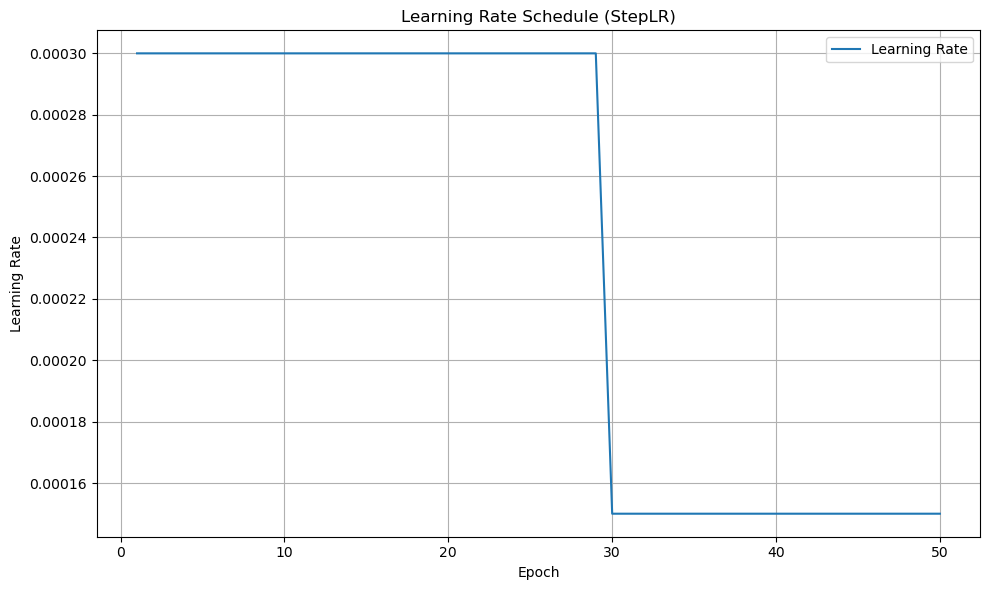

In [4]:
model, history, used_device = pipeline.train(
    epochs=epochs,
    out_dir=out_dir,
    preload_train_to_device=preload_training_data,
    early_stopping_min_delta=1e-7,
    early_stopping_patience=10,
    restore_best_weights=True,
    step_lr_step_size=30,
    step_lr_gamma=0.5,

    # --- profiler options ---
    # enable_torch_profiler=True,
    # profiler_wait_steps=5,
    # profiler_warmup_steps=3,
    # profiler_active_steps=10,
    # profiler_repeat=2,
    # profiler_row_limit=50,
)
print(f"Finished training using device: {used_device}")

In [5]:
test_and_save_forecasts(
    model,
    datasets["test_profile_ds"],
    out_dir=out_dir,
    state_dim=pipeline.config.state_dim,
    control_channel=pipeline.config.control_channel,
    target_names=pipeline.config.target_names,
    max_plots=max_plots,
    plot_callback=pipeline.plot,
    h5_path=h5_path,
)

if "cuda" in str(used_device).lower():
    print(f"Clearing {used_device}...")
    del model
    clear_cuda_cache()

Forecast profiles: 1profile [00:02,  2.01s/profile, mae_avg=6.025637e+02]

Saved forecast plot to: ../outputs/ml_results/training_playground/N501/Batch0003_k12_minmax/rolling_forecast_results_drum_profile_02004.png


Forecast profiles: 2profile [00:03,  1.93s/profile, mae_avg=3.560752e+02]

Saved forecast plot to: ../outputs/ml_results/training_playground/N501/Batch0003_k12_minmax/rolling_forecast_results_drum_profile_02006.png


Forecast profiles: 3profile [00:05,  1.95s/profile, mae_avg=4.360124e+02]

...

Saved forecast plot to: ../outputs/ml_results/training_playground/N501/Batch0003_k12_minmax/rolling_forecast_results_drum_profile_02025.png


Forecast profiles: 5profile [00:09,  1.93s/profile, mae_avg=4.895573e+02]

Saved forecast plot to: ../outputs/ml_results/training_playground/N501/Batch0003_k12_minmax/rolling_forecast_results_drum_profile_02028.png


Forecast profiles: 150profile [00:49,  3.04profile/s, mae_avg=3.267323e+02]


Testing timing summary: total_fetch: 0.0001s -  total_test: 40.5268s -  avg_fetch_profile: 0.0000s -  avg_inference_profile: 0.2702s -  save_time: 0.1527s

Clearing cuda:0...


In [ ]:
save_forecast_profiles_pdf(
    forecast_h5_path=Path("../outputs/ml_results/hp_tuning/N2001/tuning_k8/trial_0001_lb8_lr0.0001_bs128_nl1_hl256_hf256/best_model_test/rolling_forecasts.h5"),
    output_pdf_path=Path("../outputs/ml_results/hp_tuning/N2001/tuning_k8/trial_0001_lb8_lr0.0001_bs128_nl1_hl256_hf256/best_model_test/rolling_forecasts.pdf"),
)